<a href="https://colab.research.google.com/github/Sahana200301/UNIFIED-MENTOR-DATA-ANALYST-PROJECTS/blob/main/Road%20Accident%20Analysis%20India%202020%20%E2%80%93%20%20AI-Powered%20Policy%20Simulation%20and%20%20Predictive%20Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from IPython.display import display, HTML
html_content = """ <a id='1'></a> <center> <h3 style="background-color:purple; color:white"> <br>Road Accident Analysis India 2020<br> </h3> </center> """
display(HTML(html_content))

Saving Regulatory Affairs of Road Accident Data 2020 India.csv to Regulatory Affairs of Road Accident Data 2020 India (1).csv


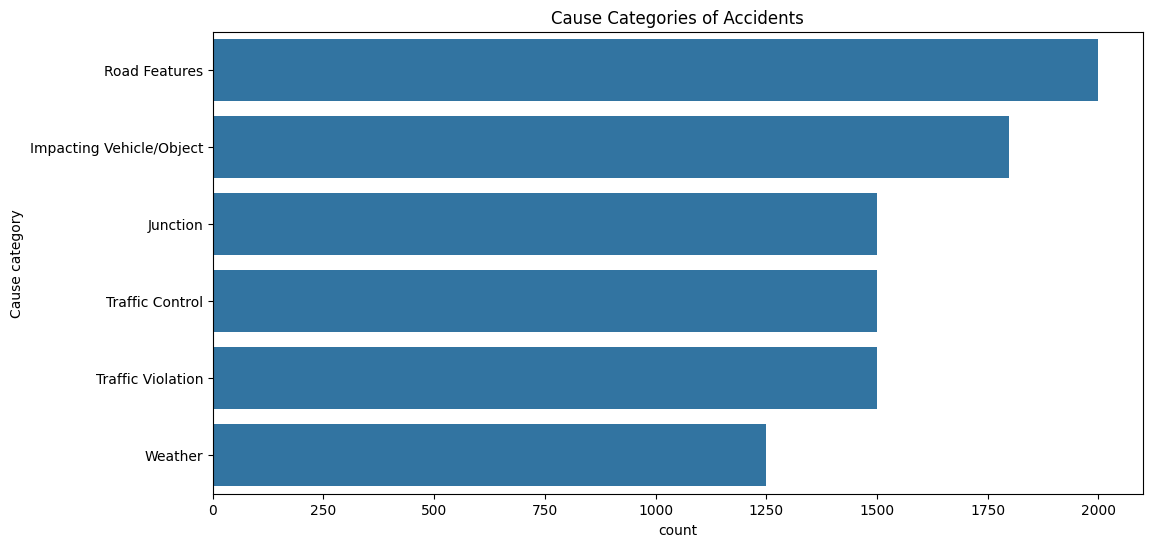

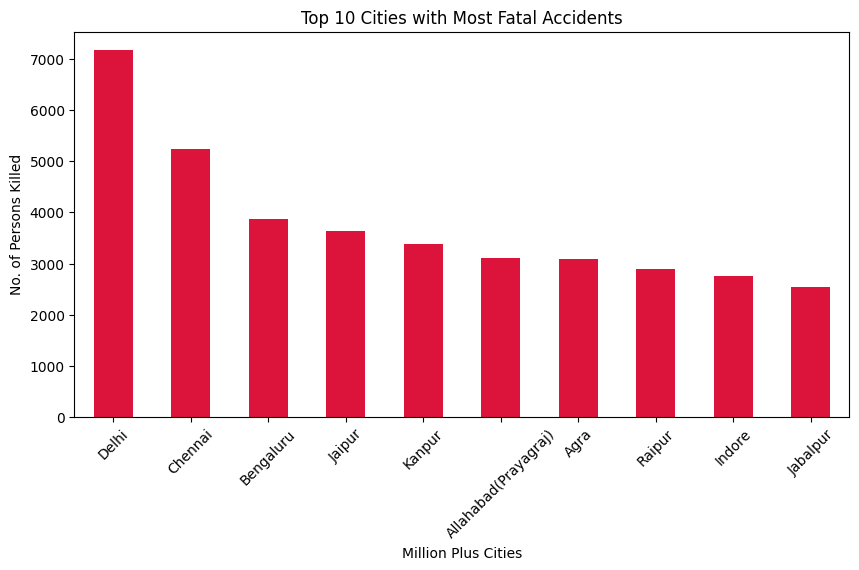

              precision    recall  f1-score   support

           0       0.80      0.89      0.84      1519
           1       0.26      0.15      0.19       391

    accuracy                           0.74      1910
   macro avg       0.53      0.52      0.52      1910
weighted avg       0.69      0.74      0.71      1910

Outcome of Incident
Greviously Injured            7782.0
Minor Injury                  2658.0
Persons Killed                2094.0
Total Injured                 8700.0
Total number of Accidents    10872.0
Name: Count, dtype: float64

Cluster Profiles:

Cluster 0:
['Bengaluru', 'Chennai', 'Delhi', 'Indore', 'Jabalpur']

Cluster 1:
['Amritsar', 'Asansol Durgapur', 'Aurangabad', 'Chandigarh', 'Coimbatore', 'Dhanbad', 'Faridabad', 'Ghaziabad', 'Jamshedpur', 'Jodhpur', 'Kannur', 'Kota', 'Lucknow', 'Ludhiana', 'Madurai', 'Meerut', 'Nagpur', 'Nashik', 'Patna', 'Pune', 'Rajkot', 'Srinagar', 'Surat', 'Tiruchirapalli', 'Vadodra', 'Varanasi']

Cluster 2:
['Bhopal', 'Hyderabad

In [ ]:
# STEP 1: Load Data

from google.colab import files
import pandas as pd

uploaded = files.upload()
df = pd.read_csv('Regulatory Affairs of Road Accident Data 2020 India.csv')
df.head()

# STEP 2: Data Cleaning

df.columns = df.columns.str.strip()
df = df.dropna(subset=['Count'])
df['Count'] = df['Count'].astype(float)
df['Cause category'] = df['Cause category'].str.strip()
df['Cause Subcategory'] = df['Cause Subcategory'].str.strip()
df['Outcome of Incident'] = df['Outcome of Incident'].str.strip()

# STEP 3: EDA

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.countplot(data=df, y='Cause category', order=df['Cause category'].value_counts().index)
plt.title("Cause Categories of Accidents")
plt.show()

fatal_df = df[df['Outcome of Incident'] == 'Persons Killed']
top_cities = fatal_df.groupby("Million Plus Cities")['Count'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_cities.plot(kind='bar', color='crimson')
plt.title("Top 10 Cities with Most Fatal Accidents")
plt.ylabel("No. of Persons Killed")
plt.xticks(rotation=45)
plt.show()

# STEP 4: Predicting Fatal Accidents (Binary Classification)

df['Fatal'] = df['Outcome of Incident'].apply(lambda x: 1 if x == 'Persons Killed' else 0)
df_encoded = pd.get_dummies(df[['Cause category', 'Cause Subcategory']], drop_first=True)

X = pd.concat([df_encoded, df[['Count']]], axis=1)
y = df['Fatal']

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# STEP 5: Policy Simulation Function (My Novelty)

def simulate_policy_impact(df, city, subcause, reduction_percent):
    df_sim = df.copy()
    condition = (df_sim['Million Plus Cities'] == city) & (df_sim['Cause Subcategory'] == subcause)
    df_sim.loc[condition, 'Count'] *= (1 - reduction_percent / 100)
    return df_sim

# Example: Simulate reducing potholes in Mumbai by 50%
sim_df = simulate_policy_impact(df, 'Mumbai', 'Pot Holes', 50)
result = sim_df[sim_df['Million Plus Cities'] == 'Mumbai'].groupby('Outcome of Incident')['Count'].sum()
print(result)

# STEP 6: City Clustering for Policy Targeting

city_grouped = df.groupby(['Million Plus Cities', 'Cause category'])['Count'].sum().unstack().fillna(0)

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(city_grouped)

city_grouped['Cluster'] = clusters
city_grouped.head()

# STEP 7: Summary & Recommendations (Display cluster-based city segmentation and insights)
print("\nCluster Profiles:")
for i in range(4):
    print(f"\nCluster {i}:")
    print(city_grouped[city_grouped['Cluster'] == i].index.tolist())

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9547 entries, 0 to 9549
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Million Plus Cities  9547 non-null   object 
 1   Cause category       9547 non-null   object 
 2   Cause Subcategory    9547 non-null   object 
 3   Outcome of Incident  9547 non-null   object 
 4   Count                9547 non-null   float64
 5   Fatal                9547 non-null   int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 522.1+ KB


In [ ]:
# Actual numbers before & after for potholes only
original = df[(df['Million Plus Cities'] == 'Mumbai') & (df['Cause Subcategory'] == 'Pot Holes')]['Count'].sum()

sim_df = simulate_policy_impact(df, 'Mumbai', 'Over Speeding', 50)
after_sim = sim_df[(sim_df['Million Plus Cities'] == 'Mumbai') & (sim_df['Cause Subcategory'] == 'Pot Holes')]['Count'].sum()

print(f"Original Count: {original}")
print(f"After 50% Reduction: {after_sim}")

#compare_policy_effect(df, 'Mumbai', 'Over Speeding', 50)

Original Count: 0.0
After 50% Reduction: 0.0


In [ ]:
df['Million Plus Cities'].dropna().unique()

array(['Agra', 'Ahmedabad', 'Allahabad(Prayagraj)', 'Amritsar',
       'Asansol Durgapur', 'Aurangabad', 'Bengaluru', 'Bhopal',
       'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Dhanbad',
       'Faridabad', 'Ghaziabad', 'Gwalior', 'Hyderabad', 'Indore',
       'Jabalpur', 'Jaipur', 'Jamshedpur', 'Jodhpur', 'Kannur', 'Kanpur',
       'Khozikode', 'Kochi', 'Kolkata', 'Kollam', 'Kota', 'Lucknow',
       'Ludhiana', 'Madurai', 'Mallapuram', 'Meerut', 'Mumbai', 'Nagpur',
       'Nashik', 'Patna', 'Pune', 'Raipur', 'Rajkot', 'Srinagar', 'Surat',
       'Thiruvanthapuram', 'Thrissur', 'Tiruchirapalli', 'Vadodra',
       'Varanasi', 'Vijaywada city', 'Vizaq'], dtype=object)

In [ ]:
df['Cause Subcategory'].dropna().unique()

array(['Flashing Signal/Blinker', 'Others', 'Police Controlled',
       'Stop Sign', 'Traffic Light Signal', 'Uncontrolled',
       'Four arm Junction', 'Round about Junction', 'Staggered Junction',
       'T', 'Y', 'Driving on Wrong side',
       'Drunken Driving/ Consumption of alcohol and drug',
       'Jumping Red Light', 'Over', 'Use of Mobile Phone', 'Bridge',
       'Culvert', 'Curved Road', 'Ongoing Road Works/Under Construction',
       'Pot Holes', 'Steep Grade', 'Straight Road', 'Auto Rickshaws',
       'Bicycles', 'Buses', 'Cars, Taxis, Vans and LMV', 'Other Non',
       'Pedestrian', 'Trucks/Lorries', 'Two Wheelers', 'Foggy and Misty',
       'Hail/Sleet', 'Rainy', 'Sunny/Clear'], dtype=object)

SIMULATION AND VISUALIZATION

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("Regulatory Affairs of Road Accident Data 2020 India.csv")

# Clean city and cause subcategory
df['Million Plus Cities'] = df['Million Plus Cities'].astype(str).str.strip().str.title()
df['Cause Subcategory'] = df['Cause Subcategory'].astype(str).str.strip().str.title()

# Display basic info
df.head()

,Million Plus Cities,Cause category,Cause Subcategory,Outcome of Incident,Count
0,Agra,Traffic Control,Flashing Signal/Blinker,Greviously Injured,0.0
1,Agra,Traffic Control,Flashing Signal/Blinker,Minor Injury,0.0
2,Agra,Traffic Control,Flashing Signal/Blinker,Persons Killed,0.0
3,Agra,Traffic Control,Flashing Signal/Blinker,Total Injured,0.0
4,Agra,Traffic Control,Flashing Signal/Blinker,Total number of Accidents,0.0


In [ ]:
df.columns

Index(['Million Plus Cities', 'Cause category', 'Cause Subcategory',
       'Outcome of Incident', 'Count'],
      dtype='object')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Function to simulate the impact of reducing a specific cause
def simulate_policy_impact(df, city, cause_subcategory, reduction_percent):
    sim_df = df.copy()

    mask = (
        (sim_df['Million Plus Cities'].str.lower() == city.lower()) &
        (sim_df['Cause Subcategory'].str.lower() == cause_subcategory.lower())
    )

    sim_df.loc[mask, 'Count'] *= (1 - reduction_percent / 100.0)

    return sim_df

# Function to compare before and after impact
def compare_policy_effect(df, city, cause_subcategory, reduction_percent):
    simulated_df = simulate_policy_impact(df, city, cause_subcategory, reduction_percent)

    group_col = 'Outcome of Incident'
    city_mask = df['Million Plus Cities'].str.lower() == city.lower()

    group_original = df[city_mask].groupby(group_col)['Count'].sum()
    group_simulated = simulated_df[city_mask].groupby(group_col)['Count'].sum()

    compare_df = pd.DataFrame({
        'Before': group_original,
        'After': group_simulated
    }).fillna(0)

    compare_df.plot(kind='bar', figsize=(12, 6), color=['orange', 'green'])
    plt.title(f"Effect of Reducing '{cause_subcategory}' by {reduction_percent}% in {city}")
    plt.ylabel("Incident Count")
    plt.xlabel("Outcome of Incident")
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def compare_policy_effect(df, city, cause_subcategory, reduction_percent):
    city_lower = city.lower()
    cause_lower = cause_subcategory.lower()

    # Simulate reduction
    sim_df = df.copy()
    mask = (
        (sim_df['Million Plus Cities'].str.lower() == city_lower) &
        (sim_df['Cause Subcategory'].str.lower() == cause_lower)
    )
    sim_df.loc[mask, 'Count'] *= (1 - reduction_percent / 100.0)

    original_count = df[mask]['Count'].sum()
    after_count = sim_df[mask]['Count'].sum()

    print(f"\n📌 Simulation Summary for '{cause_subcategory}' in {city}")
    print(f"Original Count      : {original_count}")
    print(f"After {reduction_percent}% Reduction: {after_count}\n")

    # Group by Outcome of Incident for comparison
    group_col = 'Outcome of Incident'
    city_mask = df['Million Plus Cities'].str.lower() == city_lower

    group_original = df[city_mask].groupby(group_col)['Count'].sum()
    group_simulated = sim_df[city_mask].groupby(group_col)['Count'].sum()

    compare_df = pd.DataFrame({
        'Before': group_original,
        'After': group_simulated
    }).fillna(0)

    compare_df.plot(kind='bar', figsize=(12, 6), color=['orange', 'green'])
    plt.title(f"Effect of Reducing '{cause_subcategory}' by {reduction_percent}% in {city}")
    plt.ylabel("Incident Count")
    plt.xlabel("Outcome of Incident")
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.legend()
    plt.tight_layout()
    plt.show()


📌 Simulation Summary for 'Over' in Mumbai
Original Count      : 5560.0
After 50% Reduction: 2780.0



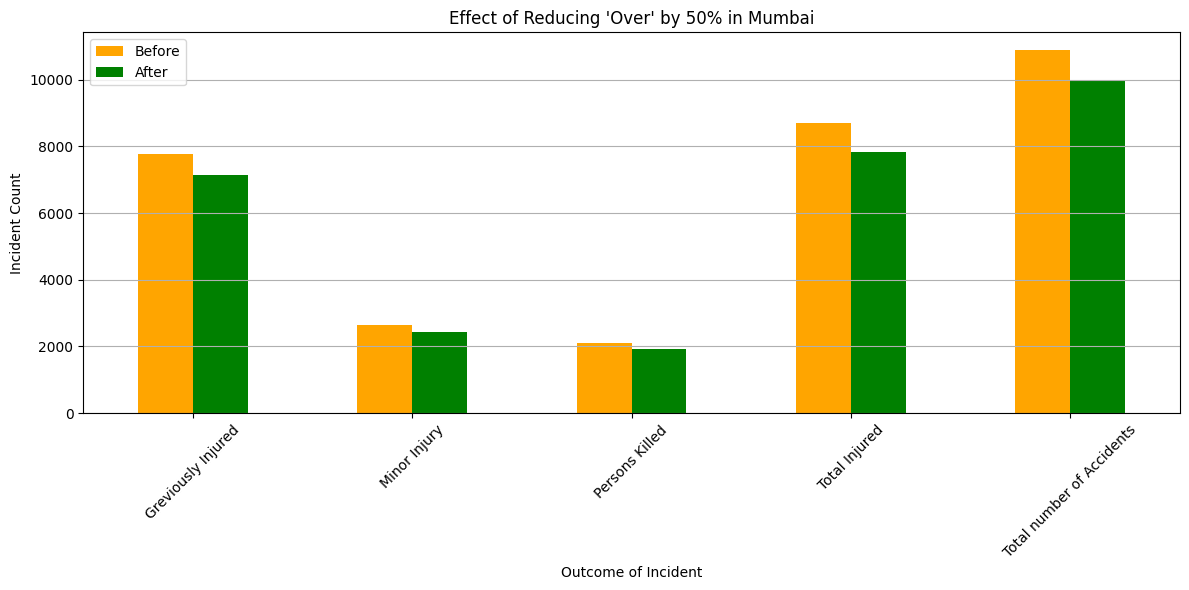

In [ ]:
# Example: Simulate reducing Pot Holes by 50% in Mumbai
compare_policy_effect(df, 'Mumbai', 'Over', 50)


📌 Simulation Summary for 'Drunken Driving/ Consumption of alcohol and drug' in Delhi
Original Count      : 457.0
After 60% Reduction: 182.8



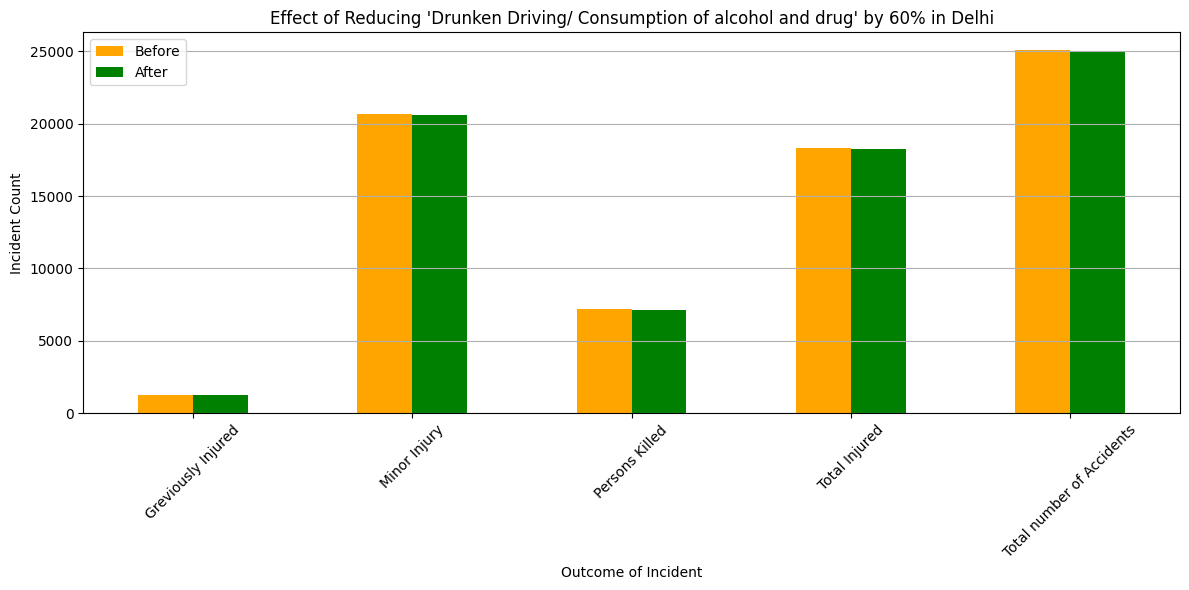

In [ ]:
compare_policy_effect(df, 'Delhi', 'Drunken Driving/ Consumption of alcohol and drug', 60)


📌 Simulation Summary for 'Jumping Red Light' in Chennai
Original Count      : 1059.0
After 50% Reduction: 529.5



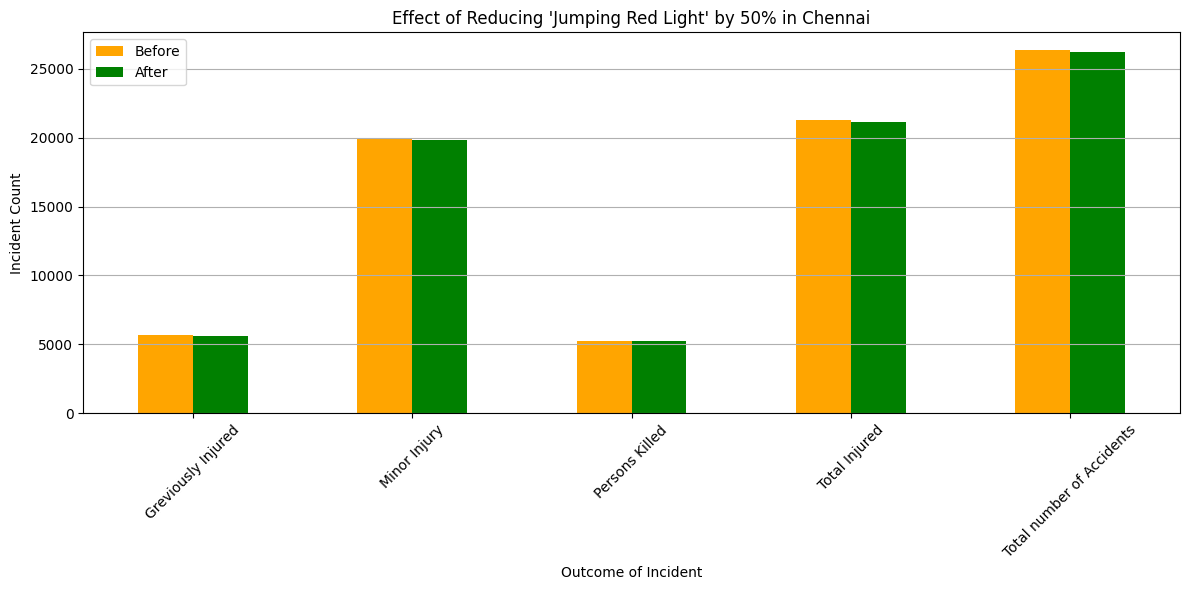

In [ ]:
compare_policy_effect(df, 'Chennai', 'Jumping Red Light', 50)

# **END**